* 라이브러리 임포트

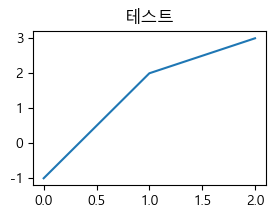

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

pd.Series([-1,2,3]).plot(title='테스트', figsize=(3,2))
pass


## 데이터 수집
* 상가상권정보<br>
https://www.data.go.kr/data/15083033/fileData.do

In [33]:
# ---------------------------
# 데이터 파일 리스트 생성
# ---------------------------

import glob

# data/폴더에서 '기상데이터'가 파일명에 포함된 모든 csv 파일
# 파일명 앞에는 한글자 이상의 다른 글자가 포함되어야 함

files = glob.glob("data/소상공인시장진흥공단_상가(상권)정보_20241231/소상공인시장진흥공단_상가(상권)정보*.csv")

# ---------------------------
# 데이터프레임 리스트 생성
# ---------------------------

df_list = []
for file in files:
    df_list.append(pd.read_csv(file, low_memory=False))

# ---------------------------
# 데이터프레임 연결
#   df_all
# ---------------------------

df_all = pd.concat(df_list ,ignore_index=True)


# ---------------------------
# 사용할 컬럼만 선택
# ---------------------------
df_stores = df_all[['상호명','상권업종대분류명','상권업종중분류명','상권업종소분류명','시도명','시군구명','행정동명','법정동명','경도', '위도']].copy()


In [34]:
df_stores.head()

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,법정동명,경도,위도
0,클러버,음식,주점,요리 주점,강원특별자치도,삼척시,정라동,정상동,129.185165,37.436915
1,최병영법률사무소,과학·기술,법무관련,변호사,강원특별자치도,인제군,인제읍,인제읍,128.173517,38.066837
2,깡통,소매,섬유·의복·신발 소매,남성 의류 소매업,강원특별자치도,원주시,일산동,일산동,127.948875,37.348471
3,금수강산컨설팅,부동산,부동산 서비스,부동산 중개/대리업,강원특별자치도,평창군,진부면,진부면,128.577368,37.659378
4,우리약초,소매,식료품 소매,채소/과일 소매업,강원특별자치도,횡성군,공근면,공근면,127.959972,37.530858


In [35]:
# ----------------------------------------
# 시도별 업종 대분류별 상가 갯수
# ----------------------------------------

df_pivot = df_stores.pivot_table(index='시도명',
                      columns='상권업종대분류명',
                      values='상호명',
                      aggfunc='count',
                      margins=True)

df_pivot

상권업종대분류명,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식,All
시도명,,,,,,,,,,,
강원특별자치도,5757,6226,1830,2525,27514,11764,8376,4195,4274,38931,111392
경기도,72241,57098,17476,30795,156125,79053,10447,28217,30389,191044,672885
경상남도,9934,7867,1413,5830,44138,22649,6620,5923,6660,65908,176942
경상북도,7757,5744,939,4048,39046,18463,6336,5191,5619,53869,147012
광주광역시,7469,4119,1093,3684,20018,11013,792,3042,3576,23342,78148
대구광역시,9692,6761,1486,4157,31475,16003,1041,4053,5116,39837,119621
대전광역시,6878,5209,1930,2557,20857,10690,721,3208,3701,24838,80589
부산광역시,13250,7736,2304,6046,40480,20868,2646,5778,6159,56172,161439
서울특별시,94499,44525,18743,25189,118697,53048,8246,24801,20902,144885,553535


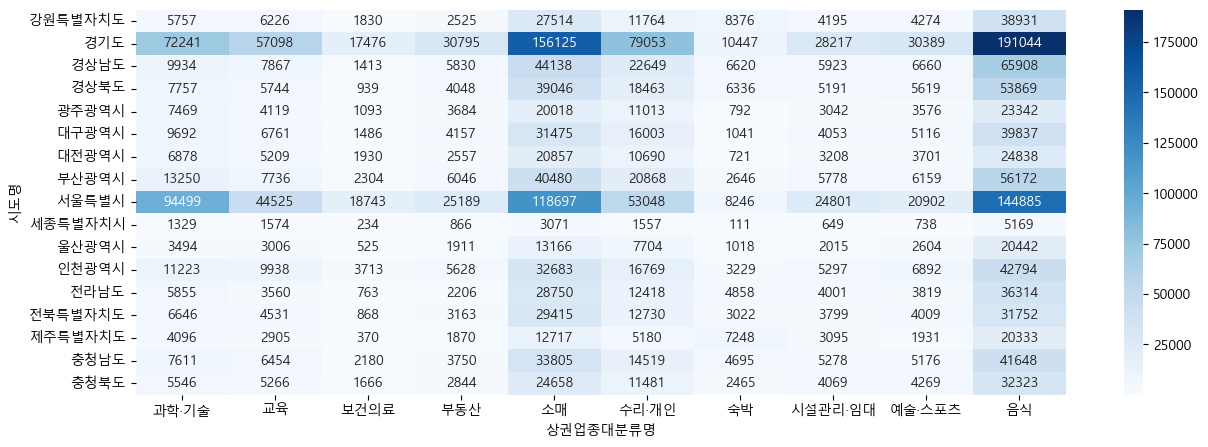

In [36]:
# ----------------------------------------
# 시도별 업종 대분류별 상가 갯수 시각화
# ----------------------------------------

plt.figure(figsize=(15,5))
sns.heatmap(df_pivot.iloc[:-1, :-1], cmap='Blues', annot=True, fmt='d');

## 시도별 상권분석

In [11]:
df = pd.read_csv("C:\\Users\\User\\Documents\\VSCode\\Data School\\data school\\00.data\\소상공인시장진흥공단_상가(상권)정보_강원_202412.csv")
df = df[['상호명','상권업종대분류명','상권업종중분류명','상권업종소분류명','시도명','시군구명','행정동명','법정동명','경도', '위도']].copy()
df.head()

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,법정동명,경도,위도
0,클러버,음식,주점,요리 주점,강원특별자치도,삼척시,정라동,정상동,129.185165,37.436915
1,최병영법률사무소,과학·기술,법무관련,변호사,강원특별자치도,인제군,인제읍,인제읍,128.173517,38.066837
2,깡통,소매,섬유·의복·신발 소매,남성 의류 소매업,강원특별자치도,원주시,일산동,일산동,127.948875,37.348471
3,금수강산컨설팅,부동산,부동산 서비스,부동산 중개/대리업,강원특별자치도,평창군,진부면,진부면,128.577368,37.659378
4,우리약초,소매,식료품 소매,채소/과일 소매업,강원특별자치도,횡성군,공근면,공근면,127.959972,37.530858


In [49]:
# ----------------------------------------
# 시도 선택
# ----------------------------------------

sido_input = input('시도명 : ')
cond = df_stores['시도명'].str.contains(sido_input)

try :
    sido_name = df_stores.loc[cond]['시도명'].drop_duplicates().iloc[0]
    print(sido_name)
except :
    print("input error")

인천광역시


In [ ]:
# ----------------------------------------
# 시도의 데이터 선택
# ----------------------------------------

cond = df['시도명']==sido_name
df_sido = df.loc[cond]

In [12]:
# ----------------------------------------
# 선택한 시도의 구별 - 업종 대분류별 상가 갯수
# ----------------------------------------

df_pivot = df.pivot_table(index='시군구명', 
                    columns='상권업종대분류명',
                    values='상호명',
                    aggfunc='count',
                    margins=True)

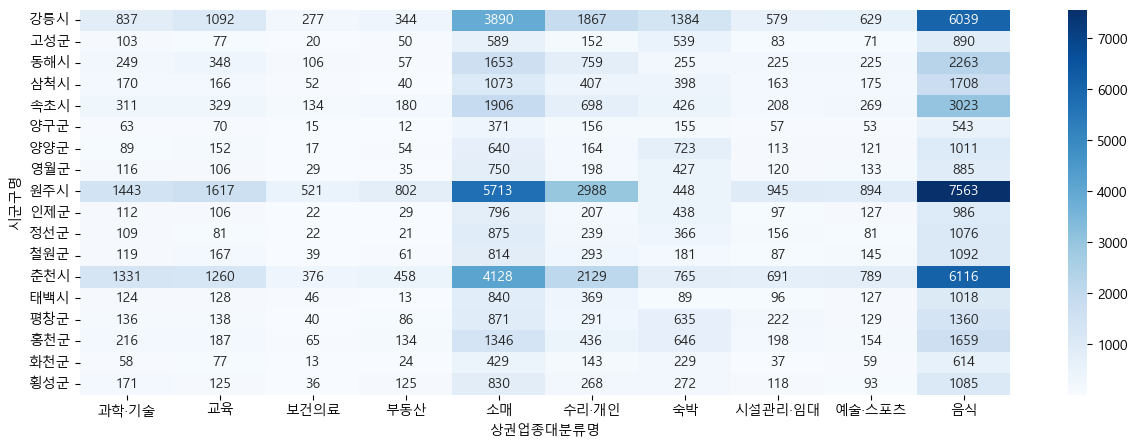

In [13]:
# ----------------------------------------
# 선택한 시도의 구별 - 업종 대분류별 상가 갯수 시각화
# ----------------------------------------

plt.figure(figsize=(15,5))
sns.heatmap(df_pivot.iloc[:-1, :-1], cmap='Blues', annot=True, fmt='d');


## 📌 분석 결과
> 강원도 내 상업 중심지 : 원주시, 춘천시, 강릉시  
- 음식, 소매, 수리·개인 업종에서 압도적인 상가 수 보유.  
- 관광지로 알려진 속초시, 양양군, 평창군, 홍천군 등은 상대적으로 숙박 업종 비중이 높음
- 고성군, 양구군, 영월군 등 인구밀도 낮은 군지역은 전반적으로 업소 수가 적음.


In [ ]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[37.8, 128.5], zoom_start=8)
cluster = MarkerCluster().add_to(m)

# '카페' 업종 필터링 후 지도에 추가
for idx, row in df[df['상권업종소분류명'].str.contains('카페', na=False)].dropna(subset=['위도', '경도']).iterrows():
    folium.Marker(
        location=[row['위도'], row['경도']],
        popup=row['상호명']
    ).add_to(cluster)

# 원주시, 춘천시, 강릉시에 빨간 원 추가
highlight_cities = {
    '원주시': [37.3422, 127.9202],
    '춘천시': [37.8813, 127.7298],
    '강릉시': [37.7519, 128.8761]
}

for city, coords in highlight_cities.items():
    folium.Circle(
        location=coords,
        radius=10000,  # 반지름 10km
        color='red',
        fill=True,
        fill_opacity=0.1,
        popup=f'{city} 중심지'
    ).add_to(m)

m
# m.save("강원도 카페.html")

## 강원도 카페 밀집도 시각화

- 카페는 유동 인구와 소비 활동이 많은 지역에 몰려 있다.

- 강원도에서 카페가 밀집된 지역은 대부분 도심(원주, 춘천)이나 관광지(강릉, 속초)다.

- 카페 분포만으로도 지역 상권의 활발한 정도를 가늠할 수 있다.

| 지역 | 특징 |
|------|------|
| **원주시** | 가장 많은 카페 밀집도 (1309개) → 강원도 최대 상업 중심지 |
| **강릉시** | 관광도시답게 해안선 주변에 900개 이상 밀집 |
| **춘천시** | 도심과 대학가 주변을 중심으로 900여 개 카페 존재 |
| **속초/양양/평창** | 관광 수요를 반영한 적정 밀집도 |
| **내륙 산간 지역** | 인제, 양구 등은 상대적으로 카페 수 적음 → 생활권 중심 상권 |